# Annotation Quality Evaluation

Analyses the quality of the LLM-produced annotation stored in
`annotation/eval_annotated.parquet`.

The annotation produces:
1. `caregiver_clear` and `caregiver_vague`
2. `time_of_day`
3. `event_time`
4. `schedule`

In this notebook we will inspect their formal and semantic correctness and correct the annotation if necessary.

## 1. Setup

In [84]:
import sys
import re
import json
import ast
import math
import random
from collections import Counter
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches

import nltk
nltk.download('wordnet',  quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('omw-1.4',  quiet=True)
from nltk.stem import WordNetLemmatizer
from nltk.corpus import stopwords

NOTEBOOK_DIR = Path().resolve()
# notebook lives at annotation/ or at project root depending on how it is run
ROOT = NOTEBOOK_DIR if (NOTEBOOK_DIR / 'annotation').is_dir() else NOTEBOOK_DIR.parent
ANN_DIR = ROOT / 'annotation'

print(f'ROOT    : {ROOT}')
print(f'ANN_DIR : {ANN_DIR}')

ROOT    : /Users/pelle/Development/GitHub/aac-mcp-agent
ANN_DIR : /Users/pelle/Development/GitHub/aac-mcp-agent/annotation


## 2. Dataset load

In [85]:
ANNOTATED_PATH  = ANN_DIR / 'eval_annotated.parquet'
FILTERED_PATH   = ANN_DIR / 'eval_filtered.parquet'
LOG_PATH        = ANN_DIR / 'annotation_log.jsonl'

df_ann = pd.read_parquet(ANNOTATED_PATH)
df_flt = pd.read_parquet(FILTERED_PATH)

print(f'Annotated  : {len(df_ann):,} rows  cols={list(df_ann.columns)}')
print(f'Filtered   : {len(df_flt):,} rows  cols={list(df_flt.columns)}')
df_ann.head(3)

Annotated  : 1,760 rows  cols=['sentence', 'concepts', 'caregiver_clear', 'caregiver_vague', 'time_of_day', 'event_time', 'schedule', 'tod_selection', 'split']
Filtered   : 1,760 rows  cols=['sentence', 'concepts']


,sentence,concepts,caregiver_clear,caregiver_vague,time_of_day,event_time,schedule,tod_selection,split
0,The blue train is going fast.,"[{'candidate_ids': [2603, 29010, 7282, 10187, ...",The child is on the train at 17:30 this afternoon,"train ride, same route",afternoon,17:30,"[{'title': 'Train ride', 'start_time': '17:30'...",predetermined,both
1,The music is too loud in here.,"[{'candidate_ids': [9851, 23811, 37486, 38106,...",The child has music practice at 16:15 this eve...,"music practice, same place",afternoon,16:15,"[{'title': 'Music practice', 'start_time': '16...",predetermined,both
2,Look at the bubbles popping.,"[{'candidate_ids': [9851, 17054, 6155, 30510, ...",He has bubble bath at 14:00 this evening,"bubble bath, same routine",afternoon,14:00,"[{'title': 'Bubble bath', 'start_time': '14:00...",predetermined,both


## 3. Data cleaning

### 3.1 Null values

In [86]:
df_ann.info()

<class 'pandas.DataFrame'>
RangeIndex: 1760 entries, 0 to 1759
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   sentence         1760 non-null   str   
 1   concepts         1760 non-null   object
 2   caregiver_clear  1760 non-null   str   
 3   caregiver_vague  1760 non-null   str   
 4   time_of_day      1760 non-null   str   
 5   event_time       1760 non-null   str   
 6   schedule         1760 non-null   object
 7   tod_selection    1760 non-null   str   
 8   split            1760 non-null   str   
dtypes: object(2), str(7)
memory usage: 354.4+ KB


There are 2 null entries.

In [87]:
df_ann[df_ann.isnull().any(axis=1)]

,sentence,concepts,caregiver_clear,caregiver_vague,time_of_day,event_time,schedule,tod_selection,split


In [88]:
before = len(df_ann)
df_ann.dropna(inplace=True)
print(f'Dropped {before - len(df_ann)} rows, the remaining are {len(df_ann)} rows.')

Dropped 0 rows, the remaining are 1760 rows.


### 3.2 Empty str values

In [89]:
# Check all the new rows except for "schedule"
text_cols = ['caregiver_clear', 'caregiver_vague', 'time_of_day', 'event_time', 'tod_selection', 'split']
empty_mask = df_ann[text_cols].apply(lambda col: col.astype(str).str.strip() == '')
empty_rows = df_ann[empty_mask.any(axis=1)]
print(f"Rows with empty srings: {len(empty_rows)}")

Rows with empty srings: 0


### 3.3 Ensure that there is no `{TIME}` left unreplaced

In [90]:
critical_cols = df_ann.columns[2:].tolist()
mask_time = df_ann[critical_cols].apply(lambda s: s.astype(str).str.contains("{TIME}", regex=False)).any(axis=1)
rows_with_time = df_ann[mask_time]
for c in rows_with_time.columns:
    for i in rows_with_time.index:
        if "{TIME}" in str(rows_with_time.loc[i, c]):
            print(f"row {i} in col {c}: {rows_with_time.loc[i, c]}")

row 1435 in col caregiver_vague: he needs to log in at {TIME}
row 1501 in col caregiver_vague: stays in chair at {TIME}


In [91]:
# TODO: refill manually or drop?

### 3.4 Ensure that both the splits are annotated.

In [92]:
df_ann["split"].value_counts()

split
both    1760
Name: count, dtype: int64

### 3.5 Ensure that the generated `time_of_day` is coherent with other generated fields.

In [93]:
TODS   = ["morning", "afternoon", "evening", "night"]
FIELDS = ["caregiver_clear", "caregiver_vague", "schedule"]

# Extract conflicts using a nested list comprehension
conflicts = [
    {"index": i, "expected": str(row["time_of_day"]).lower(), "conflict": t, "field": f, "content": row[f]}
    for i, row in df_ann.iterrows()
    for f in FIELDS
    for t in TODS if t in str(row[f]).lower() and t != str(row["time_of_day"]).lower()
]

df_conflicts = pd.DataFrame(conflicts)
print(f"Conflicts found: {len(df_conflicts)}" if not df_conflicts.empty else "No conflicts.")
display(df_conflicts)

Conflicts found: 388


,index,expected,conflict,field,content
0,1,afternoon,evening,caregiver_clear,The child has music practice at 16:15 this eve...
1,2,afternoon,evening,caregiver_clear,He has bubble bath at 14:00 this evening
2,12,afternoon,evening,caregiver_clear,The child needs the lights dimmed at 17:00 thi...
3,26,morning,afternoon,caregiver_clear,He likes the purple swing at 08:45 this afternoon
4,29,morning,night,caregiver_clear,The child is putting together the puzzle at 12...
...,...,...,...,...,...
383,1742,afternoon,morning,caregiver_clear,She makes cards for mom at 14:30 this morning
384,1748,afternoon,night,caregiver_vague,"movie time, same night"
385,1751,night,morning,caregiver_clear,She has her swimming lesson at the pool at 02:...
386,1754,afternoon,morning,caregiver_clear,She has her morning hair appointment at 14:30 ...


In [94]:
df_conflicts["field"].value_counts()

field
caregiver_clear    300
schedule            50
caregiver_vague     38
Name: count, dtype: int64

In [95]:
def global_tod_fixer(row):
    expected   = str(row["time_of_day"]).lower()
    wrong_tods = [t for t in TODS if t != expected]

    def replace_all(text):
        if not isinstance(text, str):
            return text
        for wrong in wrong_tods:
            # Replaces 'night' with 'morning' and 'Night' with 'Morning'
            text = text.replace(wrong, expected).replace(wrong.capitalize(), expected.capitalize())
        return text

    # First the caregiver_* fields, they are just text
    for col in ["caregiver_clear", "caregiver_vague"]:
        if col in row and pd.notna(row[col]):
            row[col] = replace_all(row[col])

    # The schedule field, which has a more complex structure
    if "schedule" in row and isinstance(row["schedule"], list):
        for entry in row["schedule"]:
            for key, value in entry.items():
                if isinstance(value, str):
                    entry[key] = replace_all(value)

    return row

# Apply to the whole dataset
df_ann = df_ann.apply(global_tod_fixer, axis=1)

# 4. Data analysis

### 4.1 Length distribution of both the generated inputs

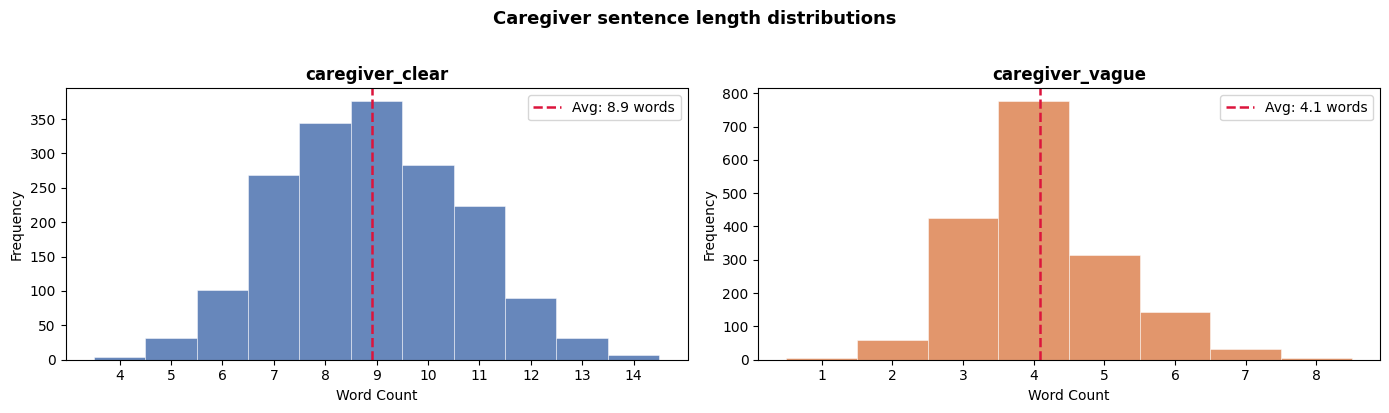

In [96]:
COLORS = {'clear': '#4C72B0', 'vague': '#DD8452'}
_df = df_ann.copy()

_df['len_clear'] = _df['caregiver_clear'].str.split().str.len()
_df['len_vague']  = _df['caregiver_vague'].str.split().str.len()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
configs = [
    (axes[0], 'len_clear', 'caregiver_clear', COLORS['clear']),
    (axes[1], 'len_vague', 'caregiver_vague', COLORS['vague'])
]

for ax, col, label, color in configs:
    vals = _df[col].dropna()
    start, end = int(vals.min()), int(vals.max())
    bins = [t - 0.5 for t in range(start, end + 2)]  # to center bin xtick
    ax.hist(vals, bins=bins, color=color, alpha=0.85, edgecolor='white', linewidth=0.4)
    avg = vals.mean()
    ax.axvline(avg, color='crimson', lw=1.8, ls='--', label=f'Avg: {avg:.1f} words')
    ax.set_xticks(range(start, end + 1, 1))
    ax.set_title(label, fontweight='bold')
    ax.set_xlabel('Word Count')
    ax.set_ylabel('Frequency')
    ax.legend()

plt.suptitle('Caregiver sentence length distributions', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 4.2 The distribution of the generated `time_of_day`.

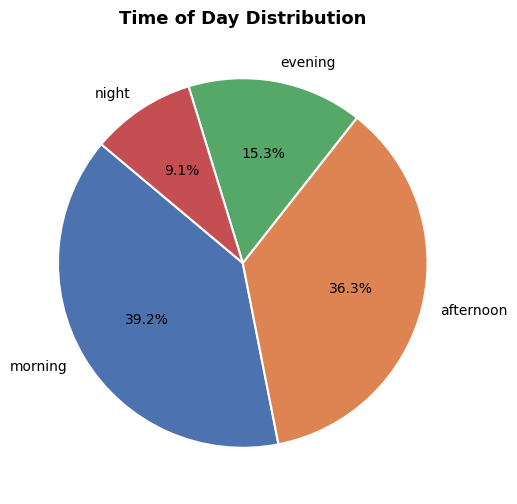

In [97]:
TOD_COLORS = {'morning': '#4C72B0', 'afternoon': '#DD8452', 'evening': '#55A868', 'night': '#C44E52'}
tod_counts = _df['time_of_day'].value_counts()
colors_pie  = [TOD_COLORS[k] for k in tod_counts.index]

fig, ax = plt.subplots(figsize=(6, 6))
wedges, texts, autotexts = ax.pie(
    tod_counts.values,
    labels=tod_counts.index,
    colors=colors_pie,
    autopct='%1.1f%%',
    startangle=140,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5},
)
for t in autotexts:
    t.set_fontsize(10)
ax.set_title('Time of Day Distribution', fontsize=13, fontweight='bold')
plt.show()

/var/folders/n9/r8x6svc56fjb_2b7zb4tztr80000gn/T/ipykernel_80673/979432747.py:11: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  parsed  = pd.to_datetime(_df['event_time'], errors='coerce')


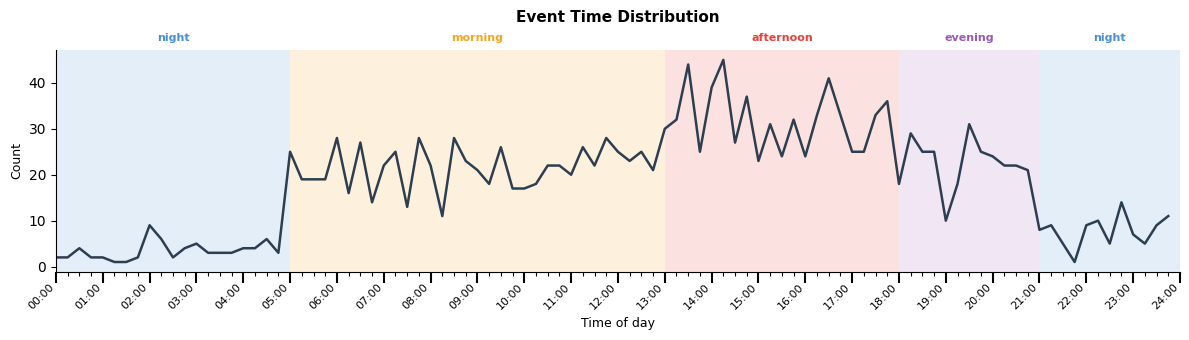

In [98]:
import matplotlib.transforms as mtransforms

_SLOT_RANGES = [
    ("night",     0,   5,  "#4A90D9"),
    ("morning",   5,  13,  "#F5A623"),
    ("afternoon", 13, 18,  "#E8423A"),
    ("evening",   18, 21,  "#9B59B6"),
    ("night",     21, 24,  "#4A90D9"),
]

parsed  = pd.to_datetime(_df['event_time'], errors='coerce')
minutes = parsed.dt.hour * 60 + parsed.dt.minute
counts  = minutes.value_counts().sort_index()

fig, ax = plt.subplots(figsize=(12, 3.5))
ax.plot(counts.index.values, counts.values, linewidth=1.8, color='#2c3e50')
ax.set_xlim(0, 1440)

# the MM where generated each 15 mins
tick_pos    = np.arange(0, 1441, 15)
tick_labels = [f"{m//60:02d}:00" if m % 60 == 0 else "" for m in tick_pos]
ax.set_xticks(tick_pos)
ax.set_xticklabels(tick_labels, rotation=45, ha='right', fontsize=8)
for tick in ax.xaxis.get_major_ticks():
    is_hour = tick.get_loc() % 60 == 0
    tick.tick1line.set_markersize(8 if is_hour else 3)
    tick.tick1line.set_markeredgewidth(1.5 if is_hour else 0.8)

# times of day colored
trans = mtransforms.blended_transform_factory(ax.transData, ax.transAxes)
for name, start, end, color in _SLOT_RANGES:
    ax.axvspan(start * 60, end * 60, alpha=0.15, color=color, linewidth=0)
    ax.text((start + end) / 2 * 60, 1.03, name,
            transform=trans, ha='center', va='bottom',
            fontsize=8, fontweight='bold', color=color, clip_on=False)

ax.set_title('Event Time Distribution', fontsize=11, fontweight='bold', pad=20)
ax.set_xlabel('Time of day', fontsize=9)
ax.set_ylabel('Count', fontsize=9)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v:,.0f}'))
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

### 4.4 Vocabulary distribution of the two kind of inputs in different times and normalized per `time_of_day`.

/var/folders/n9/r8x6svc56fjb_2b7zb4tztr80000gn/T/ipykernel_80673/465720963.py:23: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  _parsed = pd.to_datetime(_df['event_time'], errors='coerce')


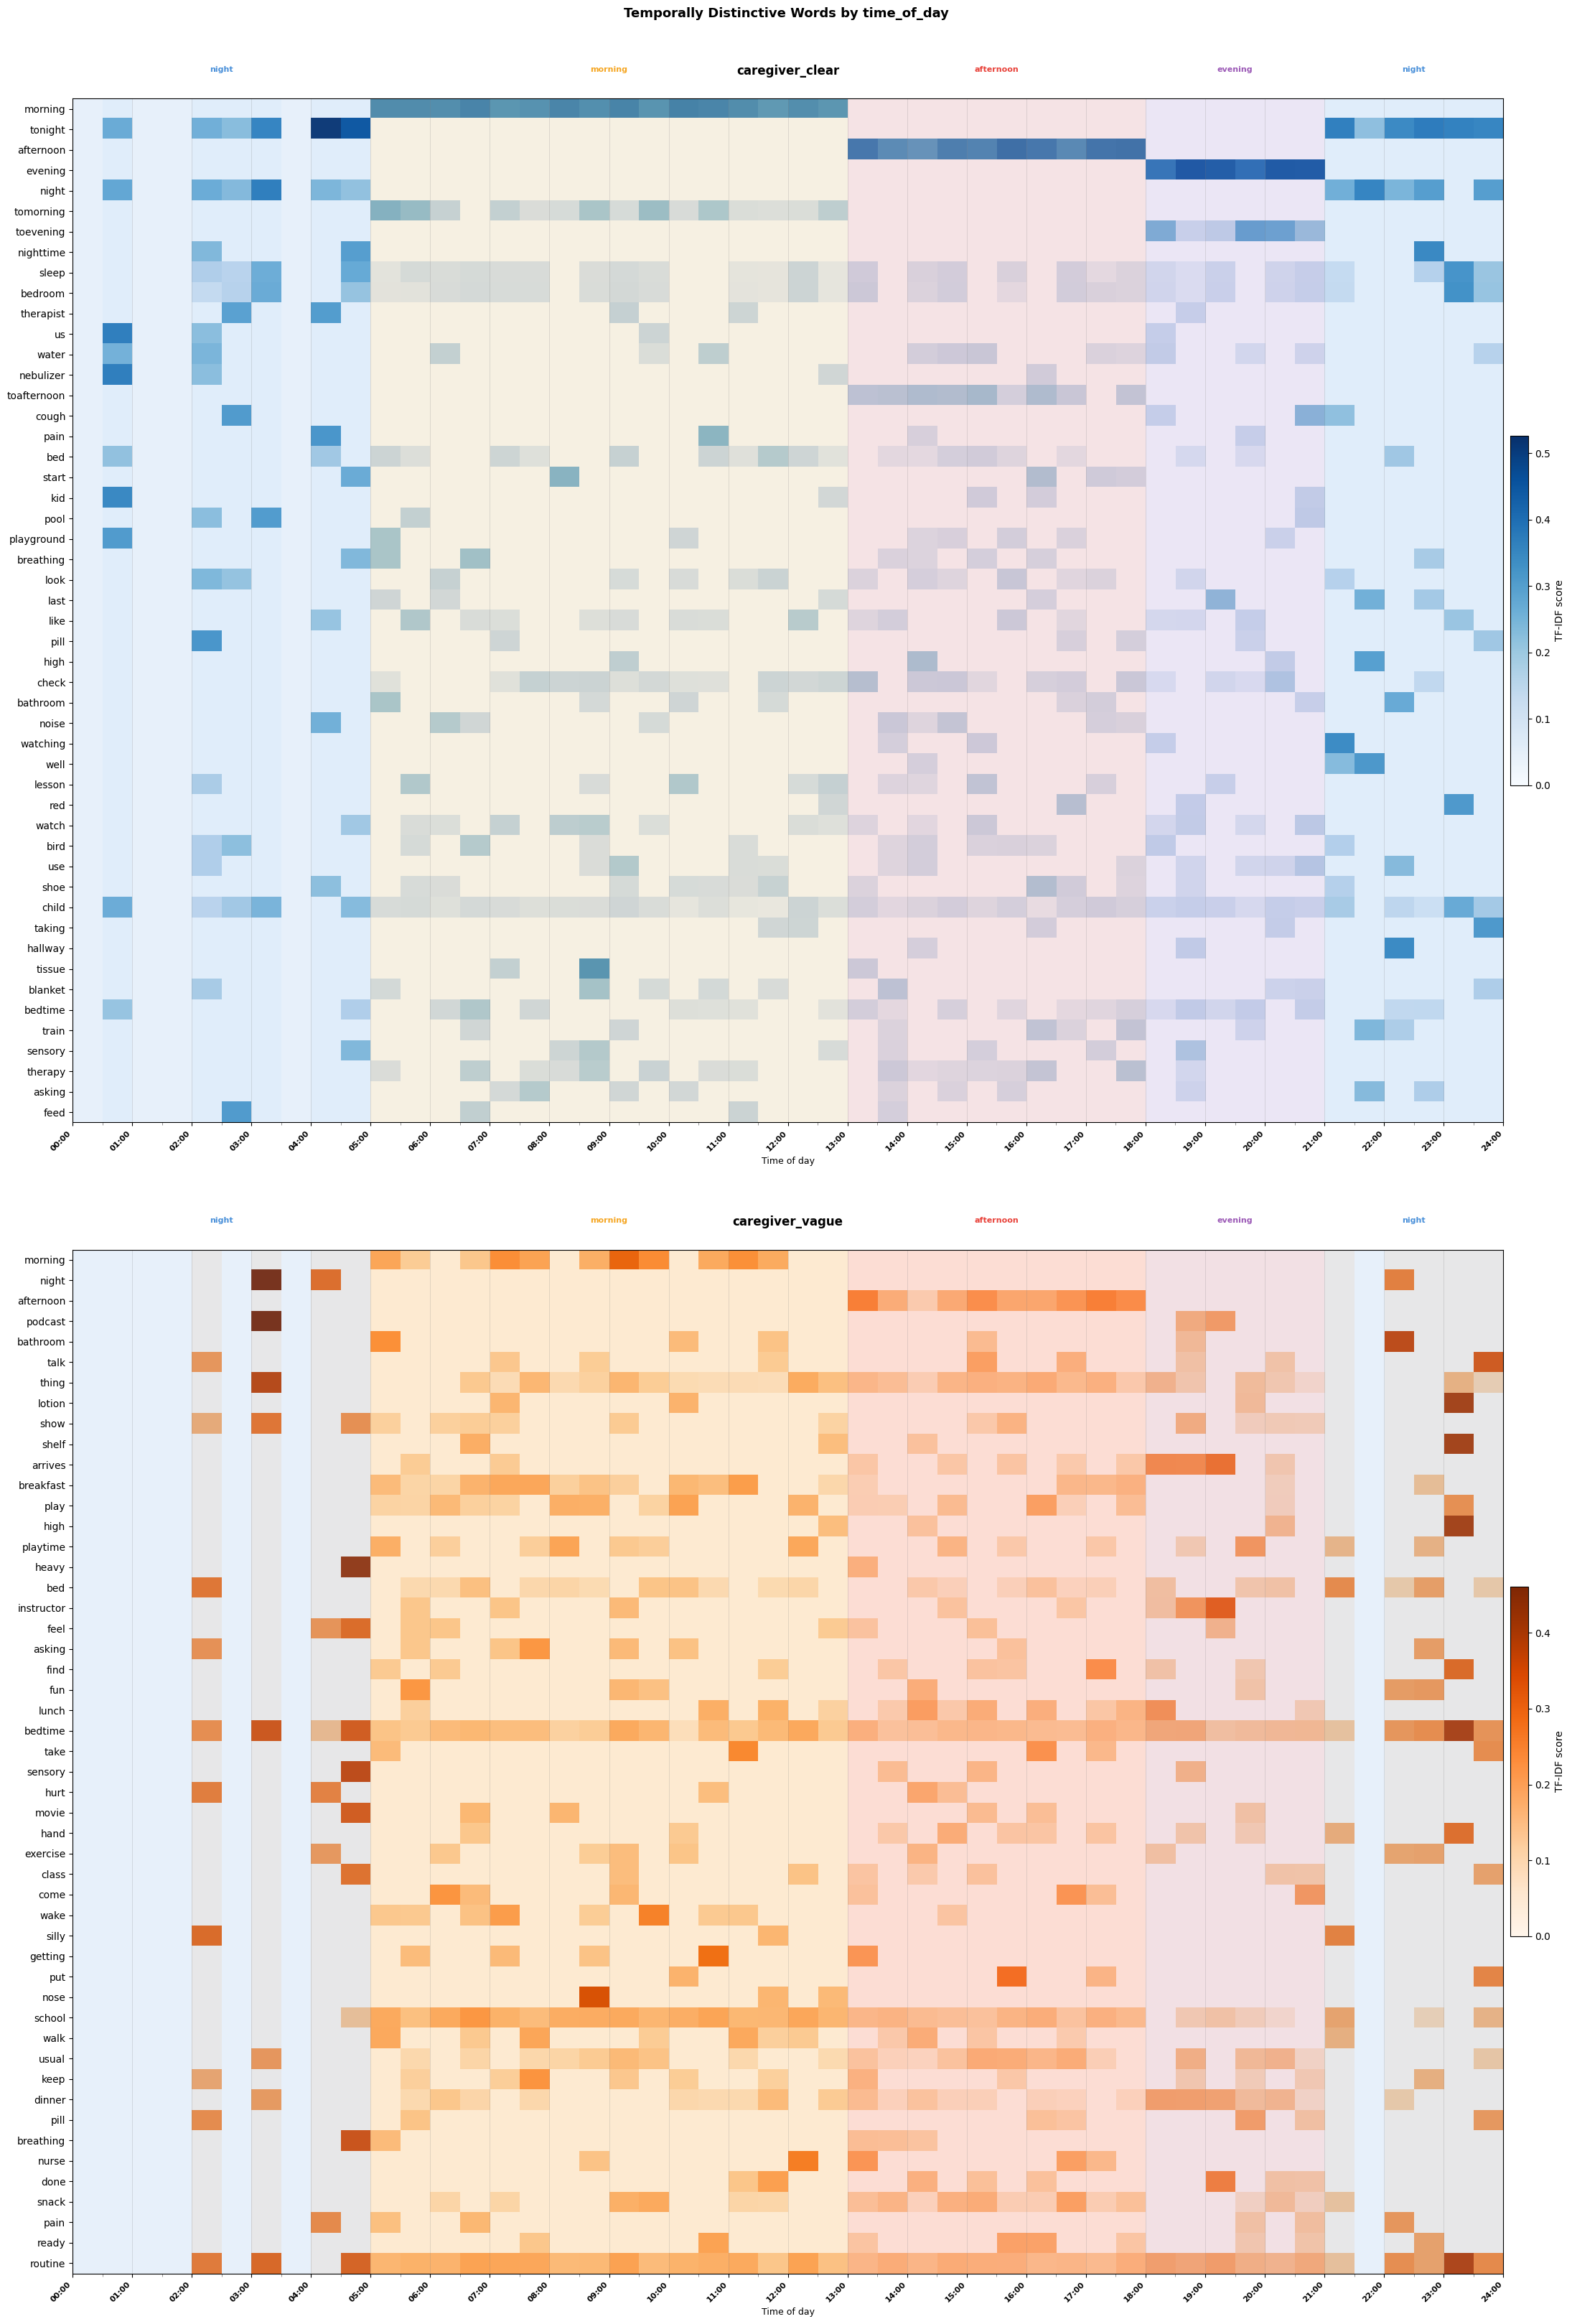

In [99]:
from sklearn.feature_extraction.text import TfidfVectorizer

_STOPWORDS  = set(stopwords.words('english'))
_lemmatizer = WordNetLemmatizer()
_TOKEN_RE   = re.compile(r'[a-z]+')

def _lemmatize_series(series: pd.Series) -> list[str]:
    """Una stringa di lemmi per ogni bin (già aggregato)."""
    out = []
    for text in series.fillna(''):
        tokens = _TOKEN_RE.findall(text.lower())
        lemmas = [
            _lemmatizer.lemmatize(t) for t in tokens
            if t not in _STOPWORDS and len(t) >= 3
        ]
        out.append(' '.join(lemmas))
    return out

BIN_MIN = 30
N_TOP = 50
MIN_BIN_TOKS = 20

_parsed = pd.to_datetime(_df['event_time'], errors='coerce')
_df['_min'] = _parsed.dt.hour * 60 + _parsed.dt.minute
_df['_bin'] = (_df['_min'] // BIN_MIN) * BIN_MIN
time_bins = list(range(0, 1440, BIN_MIN))

def _tfidf_matrix(col: str):
    bin_texts, bin_counts = {}, {}
    for b in time_bins:
        sub = _df.loc[_df['_bin'] == b, col]
        joined = ' '.join(sub.fillna('').tolist())
        lemmatized = _lemmatize_series(pd.Series([joined]))[0]
        bin_texts[b] = lemmatized
        bin_counts[b] = len(lemmatized.split())

    valid_bins = [b for b in time_bins if bin_counts[b] >= MIN_BIN_TOKS]
    docs = [bin_texts[b] for b in valid_bins]

    vec   = TfidfVectorizer(max_features=300, sublinear_tf=True)
    tfidf = vec.fit_transform(docs).toarray()
    vocab = np.array(vec.get_feature_names_out())

    # top N_TOP words by inter-bin variance
    top_idx   = np.argsort(tfidf.var(axis=0))[::-1][:N_TOP]
    top_words = vocab[top_idx].tolist()
    mat       = tfidf[:, top_idx]

    full_mat = np.full((len(time_bins), N_TOP), np.nan)
    for i, b in enumerate(valid_bins):
        full_mat[time_bins.index(b)] = mat[i]

    return full_mat, top_words

mat_clear, words_clear = _tfidf_matrix('caregiver_clear')
mat_vague, words_vague = _tfidf_matrix('caregiver_vague')

def _add_tod_bands(ax):
    trans = mtransforms.blended_transform_factory(ax.transData, ax.transAxes)
    for name, h_start, h_end, color in _SLOT_RANGES:
        ax.axvspan(h_start * 60, h_end * 60, alpha=0.13, color=color, linewidth=0, zorder=0)
        ax.text(
            (h_start + h_end) / 2 * 60, 1.025, name,
            transform=trans, ha='center', va='bottom',
            fontsize=8, fontweight='bold', color=color, clip_on=False,
        )

configs = [
    (mat_clear, words_clear, 'Blues',   'caregiver_clear'),
    (mat_vague, words_vague, 'Oranges', 'caregiver_vague'),
]

fig, axes = plt.subplots(2, 1, figsize=(22, 32))

for ax, (mat, words, cmap, title) in zip(axes, configs):
    n  = len(words)
    im = ax.imshow(
        mat.T,
        aspect='auto',
        cmap=cmap,
        interpolation='nearest',
        extent=[0, 1440, n - 0.5, -0.5],
    )
    ax.set_xlim(0, 1440)
    ax.set_xticks(range(0, 1441, 60))
    ax.set_xticklabels(
        [f"{h:02d}:00" for h in range(25)],
        rotation=45, ha='right', fontsize=8, fontweight='bold',
    )
    ax.set_xticks(range(0, 1441, BIN_MIN), minor=True)
    ax.tick_params(axis='x', which='minor', length=3, width=0.6, color='grey')
    ax.set_yticks(range(n))
    ax.set_yticklabels(words, fontsize=10)
    for h in range(25):
        ax.axvline(h * 60, color='grey', linewidth=0.4, alpha=0.4, zorder=1)
    _add_tod_bands(ax)
    ax.set_title(title, fontsize=12, fontweight='bold', pad=24)
    ax.set_xlabel('Time of day', fontsize=9)
    plt.colorbar(im, ax=ax, fraction=0.012, pad=0.005, label='TF-IDF score')

plt.suptitle(
    'Temporally Distinctive Words by time_of_day',
    fontsize=13, fontweight='bold', y=1.01,
)
plt.tight_layout(h_pad=5)
plt.show()

_df.drop(columns=['_min', '_bin'], inplace=True)

### 4.5 How much `schedule` is well formed?

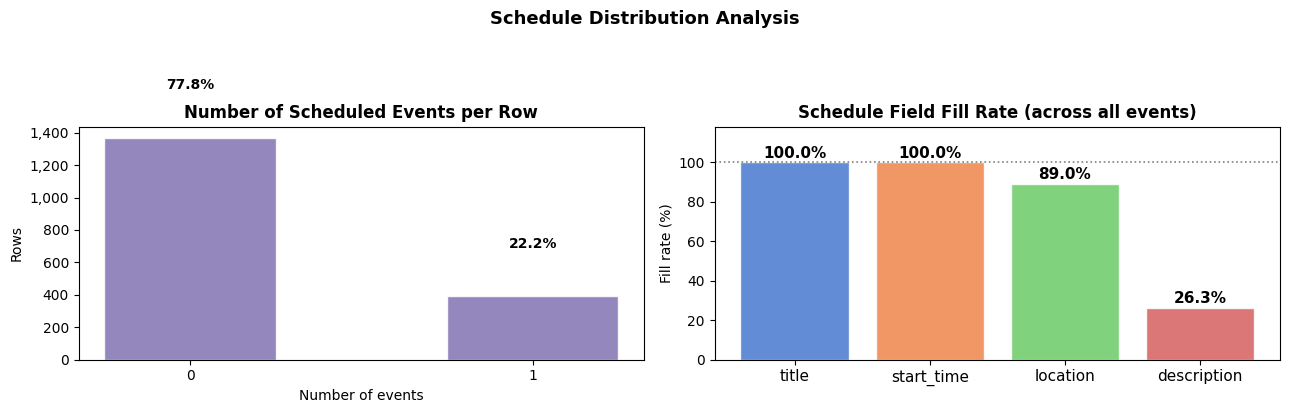

In [100]:
_df['n_events'] = _df['schedule'].apply(lambda s: len(s) if s is not None else 0)
nev_counts = _df['n_events'].value_counts().sort_index()
all_events = [ev for sched in _df['schedule'] if sched is not None for ev in sched]
fields     = ['title', 'start_time', 'location', 'description']
fill_rates = {f: sum(1 for ev in all_events if ev.get(f) is not None) / len(all_events) * 100
              for f in fields}

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# n_events distribution
bars0 = axes[0].bar(nev_counts.index.astype(str), nev_counts.values,
                    color='#8172B2', alpha=0.85, edgecolor='white', width=0.5)
for bar, (k, v) in zip(bars0, nev_counts.items()):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 300,
                 f'{v/len(_df)*100:.1f}%', ha='center', fontsize=10, fontweight='bold')
axes[0].set_title('Number of Scheduled Events per Row', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Number of events')
axes[0].set_ylabel('Rows')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

# fill-rate fields
field_colors = ['#4878D0', '#EE854A', '#6ACC65', '#D65F5F']
bars1 = axes[1].bar(fill_rates.keys(), fill_rates.values(),
                    color=field_colors, alpha=0.85, edgecolor='white')
for bar, val in zip(bars1, fill_rates.values()):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.8,
                 f'{val:.1f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')
axes[1].set_title('Schedule Field Fill Rate (across all events)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Fill rate (%)')
axes[1].set_ylim(0, 118)
axes[1].axhline(100, color='grey', linestyle=':', linewidth=1.2)
axes[1].tick_params(axis='x', labelsize=11)

plt.suptitle('Schedule Distribution Analysis', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [101]:
RNG_SEED = 42
rng = random.Random(RNG_SEED)

COLOR_REAL       = "#2a7ab5"
COLOR_DISTRACTOR = "#b8b8b8"
COLOR_EMPTY      = "#d94f3d"

DISTRACTOR_POOL = [
    # Therapies
    {"title": "Speech therapy session",      "location": "therapy centre",   "description": None},
    {"title": "Occupational therapy",        "location": "therapy centre",   "description": "fine motor skills"},
    {"title": "Physiotherapy",               "location": "rehab centre",     "description": None},
    {"title": "Music therapy",               "location": "therapy room",     "description": None},
    {"title": "Art therapy",                 "location": "therapy room",     "description": None},
    {"title": "Hydrotherapy",                "location": "pool",             "description": None},
    {"title": "Equine therapy",              "location": "riding centre",    "description": None},
    {"title": "Sensory integration session", "location": "therapy centre",   "description": None},
    {"title": "Cognitive rehabilitation",    "location": "therapy centre",   "description": None},
    {"title": "AAC device training",         "location": "therapy centre",   "description": "with speech therapist"},
    # Medical appointments
    {"title": "Pediatrician visit",          "location": "clinic",           "description": "routine check-up"},
    {"title": "Neurologist appointment",     "location": "hospital",         "description": None},
    {"title": "Audiologist check",           "location": "hospital",         "description": "hearing test"},
    {"title": "Ophthalmologist visit",       "location": "eye clinic",       "description": None},
    {"title": "Dietitian appointment",       "location": "clinic",           "description": None},
    # School
    {"title": "School bus pickup",           "location": "home",             "description": None},
    {"title": "Classroom reading session",   "location": "school",           "description": None},
    {"title": "Lunch at school",             "location": "school canteen",   "description": None},
    {"title": "Support teacher session",     "location": "school",           "description": "individual support"},
    {"title": "After-school care",           "location": "school",           "description": None},
    # Routine care
    {"title": "Medication administration",   "location": "home",             "description": "morning meds"},
    {"title": "Personal care routine",       "location": "home",             "description": "bath and dressing"},
    {"title": "Caregiver home visit",        "location": "home",             "description": None},
    {"title": "Meal prep with caregiver",    "location": "home",             "description": None},
    # Social / recreational
    {"title": "Adaptive swimming lesson",    "location": "sports centre",    "description": None},
    {"title": "Park walk with caregiver",    "location": "local park",       "description": None},
    {"title": "Playdate",                    "location": "community centre", "description": None},
    {"title": "Family lunch",                "location": "home",             "description": None},
    {"title": "Inclusive sports activity",   "location": "sports centre",    "description": None},
    {"title": "Library storytime",           "location": "public library",   "description": None},
]

# Offset pool: ±[4h00–5h00] in 15-min steps — guarantees the distractor falls
# outside any reasonable narrow time-window filter around event_time
_OFFSETS_MIN = [h * 60 + m for h in range(4, 6) for m in (0, 15, 30, 45)]


def _distractor_time(event_time_str: str) -> str:
    """Returns a start_time offset by ±[4h, 5h] from event_time, with 24h wrap."""
    base  = datetime.strptime(event_time_str, "%H:%M")
    sign  = rng.choice([-1, 1])
    delta = sign * int(rng.choice(_OFFSETS_MIN))
    h, m  = divmod((base.hour * 60 + base.minute + delta) % (24 * 60), 60)
    return f"{h:02d}:{m:02d}"


def _add_distractor(row):
    template   = rng.choice(DISTRACTOR_POOL)
    distractor = {
        "title":       template["title"],
        "start_time":  _distractor_time(row["event_time"]),
        "location":    template["location"],
        "description": template["description"],
    }
    return list(row["schedule"]) + [distractor]


df_ann["schedule"] = df_ann.apply(_add_distractor, axis=1)

# Refresh _df so subsequent analysis cells see the updated schedule
_df = df_ann.copy()

### 4.6 Are there any duplicates in the input? 

In [102]:
num_duplicates_clear = _df['caregiver_clear'].duplicated().sum()
num_duplicates_vague = _df['caregiver_vague'].duplicated().sum()
print(f"Duplicates: {num_duplicates_clear} in caregiver_clear, {num_duplicates_vague} in caregiver_vague")

Duplicates: 44 in caregiver_clear, 384 in caregiver_vague


In [103]:
_df[_df['caregiver_clear'].duplicated()]['caregiver_clear'].value_counts()[:20]

caregiver_clear
He needs a tissue at 08:30                                          3
The child is going to sleep in the bedroom at 12:00                 3
The child is going to sleep in the bedroom at 03:30                 2
The child is going to sleep in the bedroom at 23:15                 2
The child is going to sleep in the bedroom at 16:30                 2
He is going to sleep in the bedroom at 13:15                        2
You have your noise-canceling headphones at 13:30 this afternoon    1
The child is going to sleep in the bedroom at 23:45                 1
We need to go to the bathroom at 05:00 this morning                 1
We are going to the sensory room at 18:30                           1
I need a break in the quiet corner at 13:30                         1
We need more paper for the drawing at 06:00                         1
She needs to change her shoes at 16:30                              1
He takes his afternoon medication at 14:00 this afternoon           1
The 

In [104]:
_df[_df['caregiver_vague'].duplicated()]['caregiver_vague'].value_counts()[:20]

caregiver_vague
bedtime, same routine           169
the medicine before school       51
before we leave for school       10
when the instructor arrives       9
snack time, same snack            5
same bedtime                      5
playtime, same activity           4
the usual Tuesday thing           4
before I leave for work           4
before we leave for work          4
before you leave for work         3
story time, same bedtime          3
breakfast time, same routine      3
nose                              3
iPad time, same routine           3
before we go out                  3
before we leave for the park      3
nap time, same routine            3
checkup, same doctor              2
break time, same routine          2
Name: count, dtype: int64

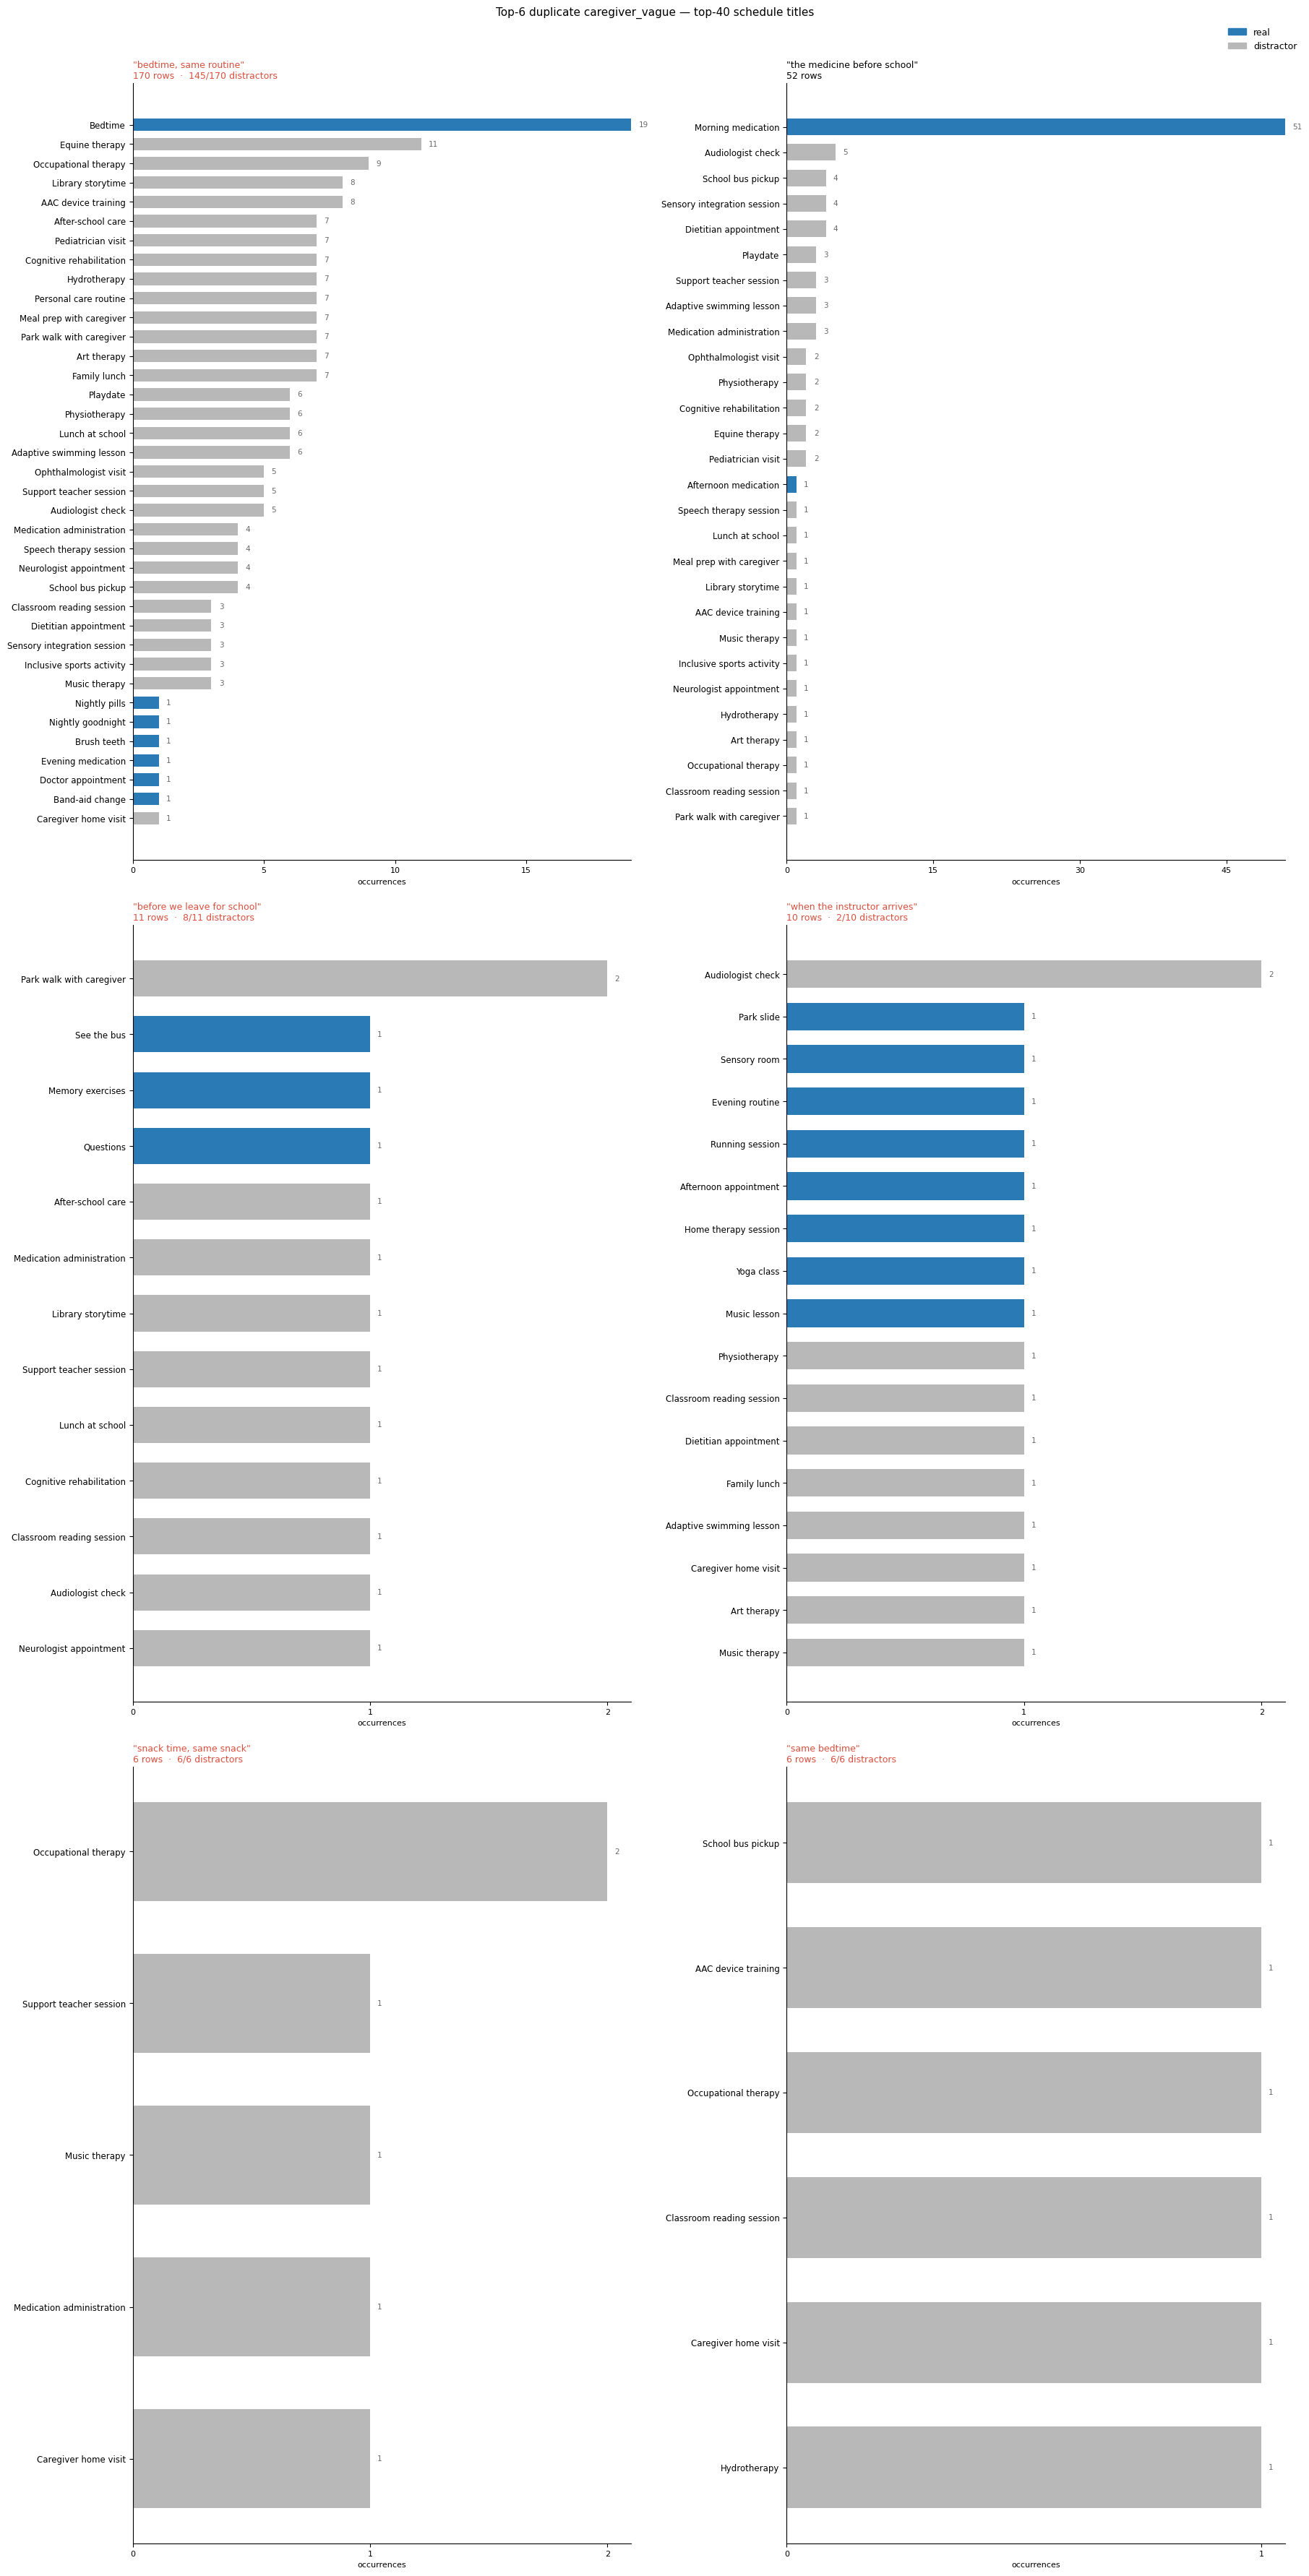

In [105]:
# A schedule event is "real"       if start_time == row event_time
# A schedule event is "distractor" if start_time != row event_time

TOP_N_VAGUE  = 6
TOP_K_TITLES = 40


def _split_titles(schedule_list, event_time: str):
    real, distractor = [], []
    if not isinstance(schedule_list, list):
        return real, distractor
    for ev in schedule_list:
        if not (isinstance(ev, dict) and "title" in ev and "start_time" in ev):
            continue
        (real if ev["start_time"] == event_time else distractor).append(ev["title"])
    return real, distractor


vague_counts = _df["caregiver_vague"].value_counts()
top_dupes    = vague_counts[vague_counts > 1].head(TOP_N_VAGUE)

panels = []
for vague_text, total_rows in top_dupes.items():
    group = _df[_df["caregiver_vague"] == vague_text]
    real_all, dist_all, no_real = [], [], 0
    for _, row in group.iterrows():
        r, d = _split_titles(row["schedule"], row["event_time"])
        if not r:
            no_real += 1
        real_all.extend(r)
        dist_all.extend(d)

    real_counts = pd.Series(real_all).value_counts()
    dist_counts = pd.Series(dist_all).value_counts()

    combined = (
        pd.concat([real_counts.rename("real"), dist_counts.rename("dist")], axis=1)
        .fillna(0).astype(int)
        .assign(total=lambda d: d["real"] + d["dist"])
        .sort_values("total", ascending=False)
        .head(TOP_K_TITLES)
    )
    panels.append((vague_text, total_rows, no_real, combined))

N_COLS = 2
N_ROWS = math.ceil(TOP_N_VAGUE / N_COLS)
ROW_H  = max(2.5, TOP_K_TITLES * 0.28)  # panel height scales with TOP_K

fig, axes = plt.subplots(N_ROWS, N_COLS, figsize=(18, N_ROWS * ROW_H + 1.2), constrained_layout=True)
axes = axes.flatten()

# hide surplus axes if TOP_N_VAGUE is odd
for ax in axes[len(panels):]:
    ax.set_visible(False)

for ax, (vague_text, total_rows, no_real, combined) in zip(axes, panels):
    y      = range(len(combined))
    labels = [t if len(t) <= 34 else t[:32] + "\u2026" for t in combined.index]

    ax.barh(y, combined["real"], color=COLOR_REAL, height=0.65, label="real")
    ax.barh(y, combined["dist"], left=combined["real"], color=COLOR_DISTRACTOR, height=0.65, label="distractor")

    ax.set_yticks(list(y))
    ax.set_yticklabels(labels, fontsize=8.5)
    ax.invert_yaxis()
    ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True, nbins=4))
    ax.tick_params(axis="x", labelsize=8)
    ax.set_xlabel("occurrences", fontsize=8)
    ax.spines[["top", "right"]].set_visible(False)

    # inline totals
    max_total = combined["total"].max()
    for i, tot in enumerate(combined["total"]):
        ax.text(tot + max_total * 0.015, i, str(tot),
                va="center", ha="left", fontsize=7.5, color="dimgray")

    # panel title
    short = f'"{vague_text}"' if len(vague_text) <= 36 else f'"{vague_text[:34]}\u2026"'
    no_real_str = f"  \u00b7  {no_real}/{total_rows} distractors" if no_real > 0 else ""
    ax.set_title(
        f"{short}\n{total_rows} rows{no_real_str}",
        fontsize=9, loc="left", pad=5,
        color=COLOR_EMPTY if no_real > 0 else "black",
    )

legend_patches = [
    mpatches.Patch(color=COLOR_REAL,       label="real"),
    mpatches.Patch(color=COLOR_DISTRACTOR, label="distractor"),
]
fig.legend(handles=legend_patches, loc="upper right", fontsize=9, frameon=False, bbox_to_anchor=(1.0, 1.015))
fig.suptitle(
    f"Top-{TOP_N_VAGUE} duplicate caregiver_vague \u2014 top-{TOP_K_TITLES} schedule titles",
    fontsize=11, y=1.02,
)
plt.show()

# 5. Save final eval dataset